In [1]:
import pandas as pd
import numpy as np
import torch

# Import the Supervised System modules
import generate_data
import build_train_model
import viz_monitor

# Reload magic to capture any script updates
%load_ext autoreload
%autoreload 2

print("Supervised Risk Velocity System Loaded.")

Supervised Risk Velocity System Loaded.


In [2]:
# Generate data with rich physics (Time-to-Cut, Facility Load)
# The model sees the physics, but NOT the 'Root_Cause_Type' text label.
packages_df, scans_df, _, _ = generate_data.run_simulation()

print(f"\nSimulation Stats:")
print(f"  - Total Packages: {len(packages_df):,}")
print(f"  - Total Scans:    {len(scans_df):,}")
print(f"  - Failure Rate:   {packages_df['FailedService'].mean():.1%}")

--- Generating Data (Supervised + Rich Physics) ---

Simulation Stats:
  - Total Packages: 69,332
  - Total Scans:    271,026
  - Failure Rate:   14.9%


In [3]:
# Setup the Supervised System
# 'calendar_df' is None because v2.1 data has context features embedded in the scan rows
model, optimizer, loaders, device, scheduler = build_train_model.setup_system(packages_df, scans_df, calendar_df=None)

print(f"\nModel Architecture Ready ({device}):")
print(f"  - Type: DeepContextualLogisticsTransformer (Supervised)")
print(f"  - Parameters: {sum(p.numel() for p in model.parameters()):,}")

Temporal Split Strategy: Train (Days 0-10) vs Val (Days 11+)
Training Packages: 54486 | Validation Packages: 14846


/home/chuck/.python_stuff/WorkingDir/service_aidir/build_train_model.py:56: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.transformer = nn.TransformerEncoder(enc_layer, num_layers=config.num_layers)



Model Architecture Ready (cuda):
  - Type: DeepContextualLogisticsTransformer (Supervised)
  - Parameters: 675,010


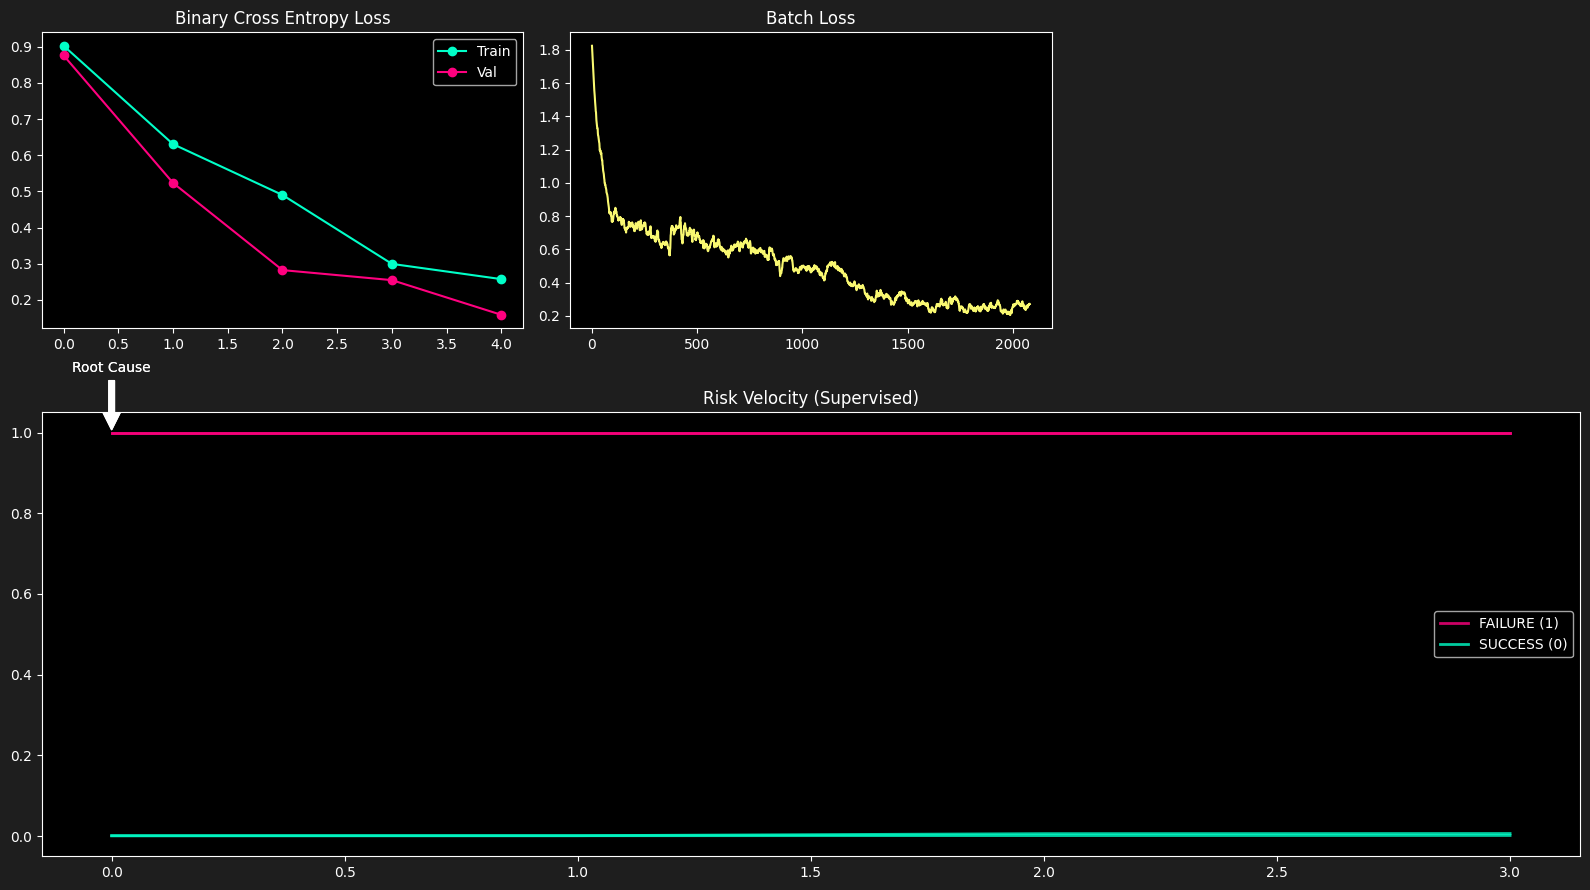

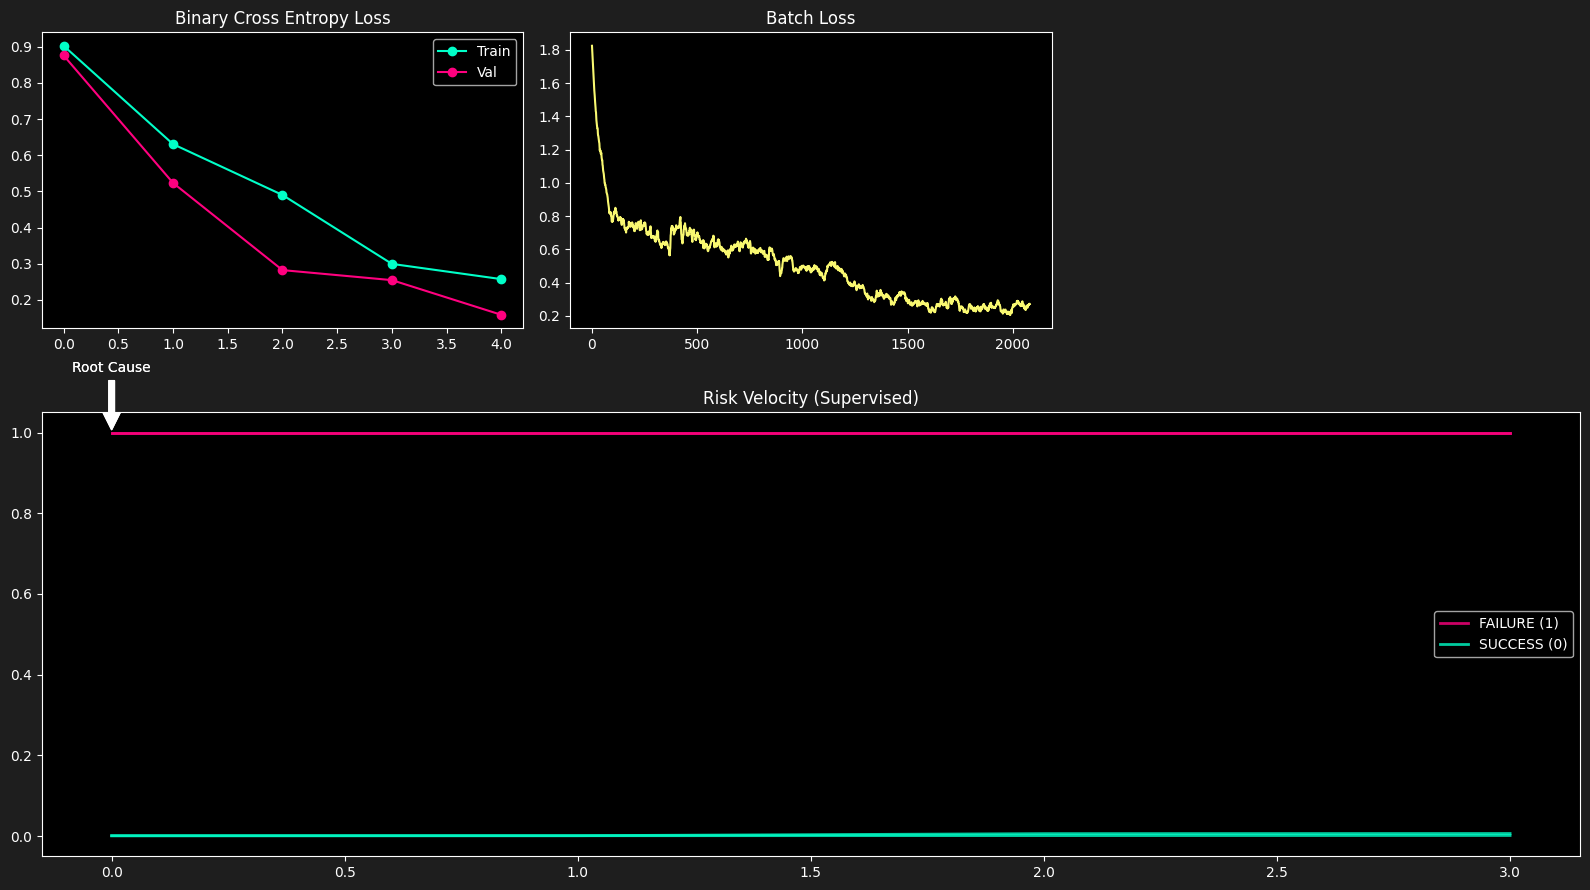

In [4]:
# Execute Training Loop with DarkMonitor
# This tracks Binary Cross Entropy Loss and plots the Step-wise Risk Curves
viz_monitor.execute_training(model, optimizer, loaders, device, epochs=5, scheduler=scheduler)